In [1]:
# Phase 1: Data Ingestion & Pit Stop Calculation
import fastf1
import pandas as pd
import os

print("Extracting Pit Stop Data!\n")

cache_dir = 'fi_score'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache(cache_dir)

year = 2023
rounds_to_fetch = [1, 2, 3, 4, 5]

all_pit_stops = []

for current_round in rounds_to_fetch:
    print(f"fetching Round {current_round}...")
    try:
        session = fastf1.get_session(year, current_round, 'R')
        session.load(telemetry=False, weather=False, messages=False)
        laps = session.laps

        pit_in_laps = laps[laps['PitInTime'].notna()]

        for index, in_lap in pit_in_laps.iterrows():
            driver = in_lap['Driver']
            lap_num = in_lap['LapNumber']

            out_lap = laps[(laps['Driver'] == driver) & (laps['LapNumber'] == lap_num + 1)]
            
            if not out_lap.empty:
                pit_in = in_lap['PitInTime']
                pit_out = out_lap.iloc[0]['PitOutTime']

                duration = (pit_out - pit_in).total_seconds()

                if duration < 100:
                    all_pit_stops.append({
                        'Round': current_round,
                        'Driver': driver,
                        'Lap': lap_num,
                        'Compound': out_lap.iloc[0]['Compound'],
                        'PitLane_Duration_Sec': duration
                    })
    except Exception as e:
        print(f"Skipping Round {current_round} due to error: {e}")

if not all_pit_stops:
    print("\n CRITICAL ERROR: No pit stops extracted.")
else:
    pit_df = pd.DataFrame(all_pit_stops)
    print("\n Pit Stop Data Extracted Successfully!")
    print("-"*70)
    print(pit_df.head(10))
    print(f"\nTotal Pit Stop recorded: {len(pit_df)}")

Extracting Pit Stop Data!

fetching Round 1...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

fetching Round 2...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

fetching Round 3...


...

fetching Round 4...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

fetching Round 5...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _exten


 Pit Stop Data Extracted Successfully!
----------------------------------------------------------------------
   Round Driver   Lap Compound  PitLane_Duration_Sec
0      1    VER  14.0     SOFT                24.297
1      1    VER  36.0     HARD                24.937
2      1    GAS   9.0     HARD                25.906
3      1    GAS  25.0     HARD                24.922
4      1    GAS  40.0     SOFT                24.749
5      1    PER  17.0     SOFT                24.281
6      1    PER  34.0     HARD                25.062
7      1    ALO  14.0     HARD                25.781
8      1    ALO  34.0     HARD                24.844
9      1    LEC  13.0     HARD                24.421

Total Pit Stop recorded: 136



Starting Phase 2: Anomaly detection with Isolation Forest...



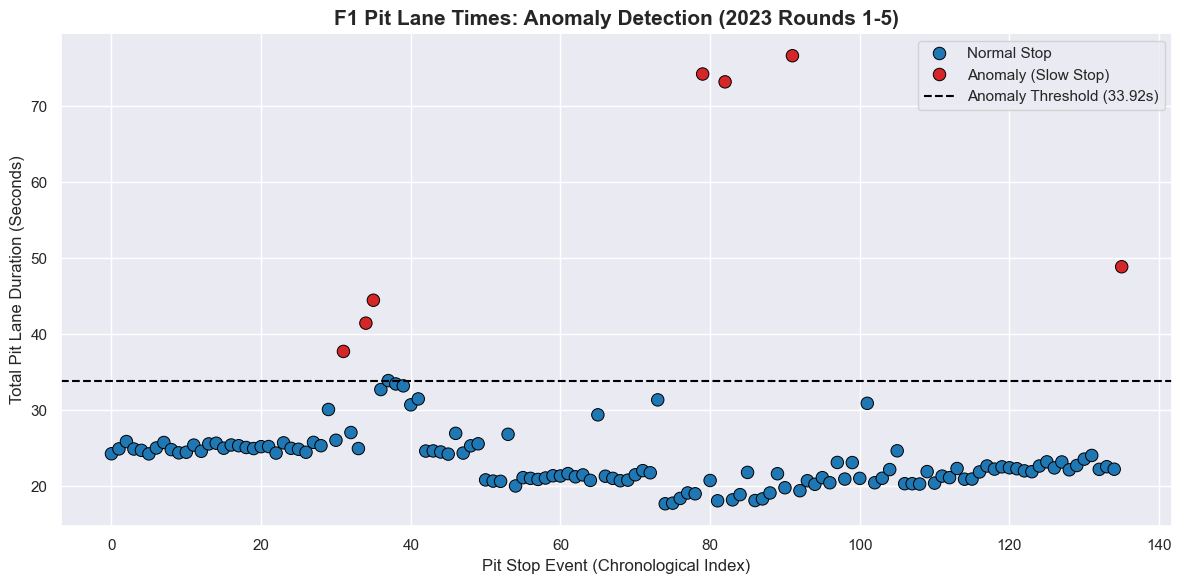

 ANOMALIES DETECTED (The Botched Pit Stops)
----------------------------------------------------------------------
     Round Driver   Lap Compound  PitLane_Duration_Sec
91       3    BOT  55.0     SOFT                76.671
79       3    SAR  55.0     SOFT                74.265
82       3    DEV  55.0     SOFT                73.233
135      5    SAR   2.0     HARD                48.906
35       1    OCO  32.0     HARD                44.499
34       1    OCO  15.0     HARD                41.484
31       1    HUL  26.0     HARD                37.765


In [2]:
# Phase 2: Building the Isolation Forest
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

print("\nStarting Phase 2: Anomaly detection with Isolation Forest...\n")

iso_forest = IsolationForest(contamination=0.05, random_state=42)

pit_df['Anomaly_Label'] = iso_forest.fit_predict(pit_df[['PitLane_Duration_Sec']])

pit_df['Status'] = pit_df['Anomaly_Label'].map({1: 'Normal Stop', -1: 'Anomaly (Slow Stop)'})

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=pit_df,
    x=pit_df.index,
    y='PitLane_Duration_Sec',
    hue='Status',
    palette={'Normal Stop':'#1f77b4','Anomaly (Slow Stop)': '#d62728'},
    s=80,
    edgecolor='black'
)

plt.title('F1 Pit Lane Times: Anomaly Detection (2023 Rounds 1-5)', fontsize=15, fontweight='bold')
plt.xlabel('Pit Stop Event (Chronological Index)', fontsize=12)
plt.ylabel('Total Pit Lane Duration (Seconds)', fontsize=12)

anomaly_threshold = pit_df[pit_df["Status"] == 'Normal Stop']['PitLane_Duration_Sec'].max()
plt.axhline(y=anomaly_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Anomaly Threshold ({anomaly_threshold:.2f}s)')
plt.legend()
plt.tight_layout()
plt.show()

anomalies_df = pit_df[pit_df['Status'] == 'Anomaly (Slow Stop)'].sort_values('PitLane_Duration_Sec', ascending=False)

print(" ANOMALIES DETECTED (The Botched Pit Stops)")
print("-"*70)
print(anomalies_df[['Round','Driver','Lap','Compound','PitLane_Duration_Sec']].head(10))


Strating Phase 3: Pit Crew Performance Analysis..

Pit Crew Permance Leaderboard (Sorted by Median Speed)
--------------------------------------------------------------------------------
Driver  Total_Stops  Fastest_Stops  Median_Time  Botched_Stops  Error_Rate_%
   PER            7          17.72        20.67              1         14.29
   RUS            7          19.14        21.36              1         14.29
   PIA            4          19.44        21.62              1         25.00
   BOT           12          19.83        21.94              1          8.33
   OCO            7          18.14        21.94              1         14.29
   LEC            5          20.06        22.05              1         20.00
   SAI            6          18.36        22.12              1         16.67
   HAM            5          20.31        22.19              1         20.00
   ZHO            9          18.92        22.22              1         11.11
   TSU            7          18.23        2

C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_20540\3886828929.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crew_df, x='Driver', y='Median_Time', palette='viridis')


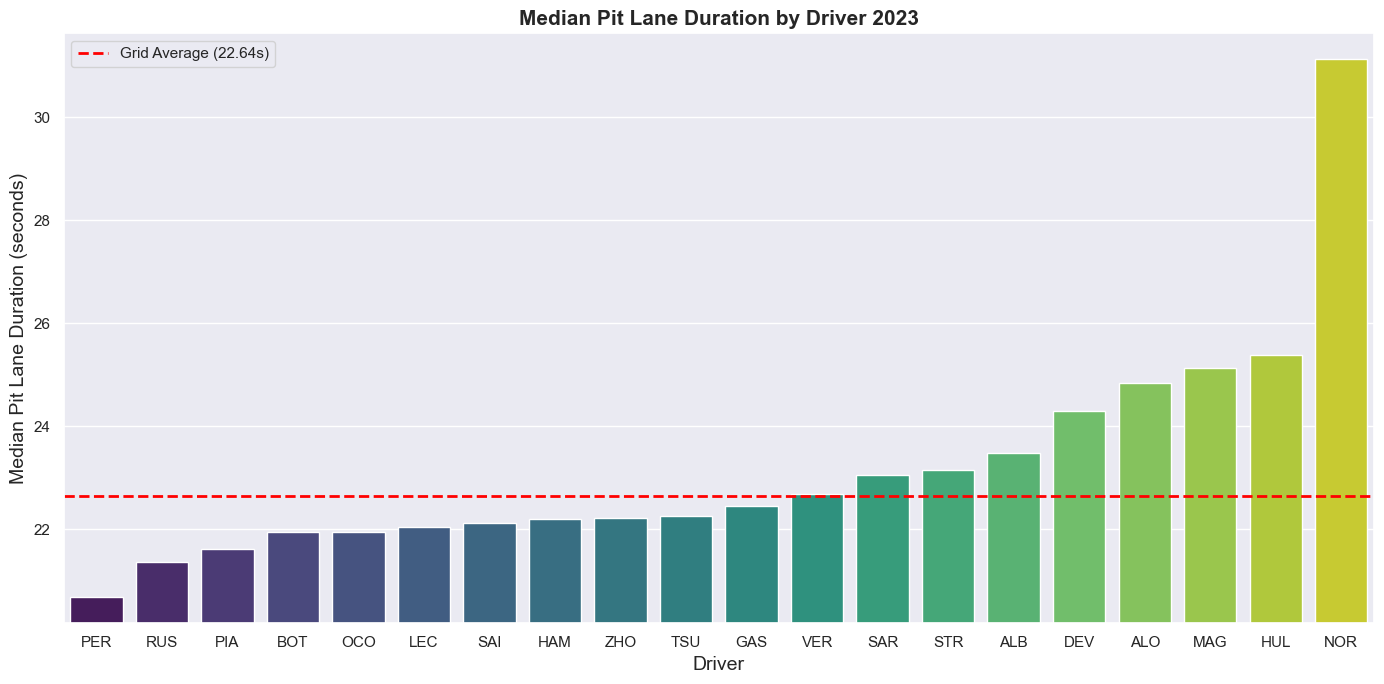

In [3]:
# Phase 3: The Pit Stop Leaderboard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Strating Phase 3: Pit Crew Performance Analysis..\n")

crew_stats = []

for driver, group in pit_df.groupby('Driver'):
    total_stops = len(group)

    median_time = group['PitLane_Duration_Sec'].median()

    botched_stops = len([group['Status'] == 'Anomaly (Slow Stop)'])
    
    error_rate = (botched_stops / total_stops)*100

    crew_stats.append({
        'Driver': driver,
        'Total_Stops': total_stops,
        'Fastest_Stops': group['PitLane_Duration_Sec'].min(),
        'Median_Time': median_time,
        'Botched_Stops': botched_stops,
        'Error_Rate_%': error_rate
    })

crew_df = pd.DataFrame(crew_stats)

crew_df = crew_df[crew_df['Total_Stops'] >=3].sort_values('Median_Time')

print("Pit Crew Permance Leaderboard (Sorted by Median Speed)")
print("-"*80)
print(crew_df.head(10).to_string(index=False, float_format="%.2f"))

plt.figure(figsize=(14, 7))

sns.barplot(data=crew_df, x='Driver', y='Median_Time', palette='viridis')

plt.title(f'Median Pit Lane Duration by Driver {year}', fontsize=15, fontweight='bold')
plt.xlabel('Driver', fontsize=14)
plt.ylabel('Median Pit Lane Duration (seconds)', fontsize=14)

min_y = crew_df['Median_Time'].min() - 0.5
max_y = crew_df['Median_Time'].max() + 0.5
plt.ylim(min_y, max_y)

grid_average = pit_df['PitLane_Duration_Sec'].median()
plt.axhline(y=grid_average, color='red', linestyle='--', linewidth=2, label=f'Grid Average ({grid_average:.2f}s)')

plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

print("Deploying Live Pit Wall Alert System...\n")

def analyze_live_pit_stop(driver, lap, duration_sec, anomaly_model):
    
    input_data = pd.DataFrame({'PitLane_Duration_Sec': [duration_sec]})
    
    prediction = anomaly_model.predict(input_data)[0]
    
    print(f"🏎️ LIVE PIT STOP: {driver} (Lap {lap})")
    print(f"⏱️ Pit Lane Time: {duration_sec:.2f}s")
    
    if prediction == 1:
        print("✅ STATUS: CLEAN STOP. Send them out!\n")
    else:
        print("🚨 STATUS: ANOMALY DETECTED! Review footage for wheel gun or jack failures.\n")


Deploying Live Pit Wall Alert System...



In [5]:
import joblib

joblib.dump(iso_forest, 'iso_forest_model.pkl')

print("Model successfully saved as 'iso_forest_model.pkl'!")

Model successfully saved as 'iso_forest_model.pkl'!
